# Corneal permeability model

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors, AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score,
)
from sklearn.metrics import (
    classification_report, f1_score, roc_curve, auc, roc_auc_score,
    accuracy_score,
)

from xgboost import XGBClassifier

import joblib

# Single source of truth for every split, model fit and figure below.
RANDOM_STATE = 42
N_SEEDS = 5


## Load dataset

In [16]:
df_full = pd.read_csv('corneal_raw.csv')
print('Total rows:', len(df_full))
print('Duplicated SMILES:', df_full['smiles'].duplicated().sum())
print()
print('Compounds per source study:')
print(df_full['title'].value_counts())


Total rows: 163
Duplicated SMILES: 1

Compounds per source study:
title
Permeability of cornea, sclera, and conjunctiva: a literature analysis for drug delivery to the eye        89
Prediction of corneal permeability using artificial neural networks                                        45
Corneal and conjunctival drug permeability: Systematic comparison and pharmacokinetic impact in the eye    14
Quantitative and qualitative prediction of corneal permeability for drug-like compounds                     8
Prediction of the Corneal Permeability of Drug-Like Compounds                                               7
Name: count, dtype: int64


### Dataset provenance

The corneal permeability dataset combines **5 independent ex vivo (rabbit cornea) studies**. Below we quantify how many compounds come from each source and check for cross-study duplicates.

### Deduplication

One compound is reported in two review papers with an identical measured
value. It is removed so that the modelling set matches the 162 compounds
reported in the manuscript.


In [17]:
df_full = df_full.drop_duplicates(subset='smiles').reset_index(drop=True)
print('Unique compounds used for modelling:', len(df_full))


Unique compounds used for modelling: 162


## Statistic

n = 162   median = -5.149
class balance: 81 high / 81 low


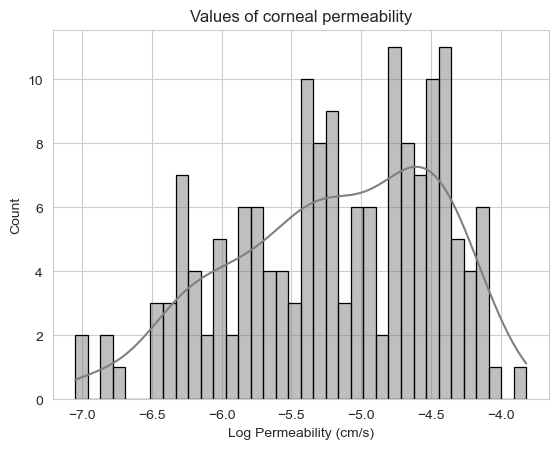

In [ ]:
# Median of the deduplicated modelling set, used for every label below.
median = float(np.median(df_full['logP']))
y_full = (df_full['logP'] >= median).astype(int).values   
smiles_arr = df_full['smiles'].values

print(f"n = {len(df_full)}   median = {median:.3f}")
print(f"class balance: {int(y_full.sum())} high / {int((1 - y_full).sum())} low")

sns.histplot(df_full['logP'], bins=36, kde=True, color='gray',
             edgecolor='black')
plt.title('Values of corneal permeability')
plt.xlabel('Log Permeability (cm/s)')
plt.show()


The threshold is the median of the pooled dataset rather than a hardcoded
value, so the labelling follows the data if the dataset is ever updated.


### Is a median split the right choice?

There is no single, universally accepted absolute cutoff for "high" vs "low"
corneal permeability in the ophthalmic literature — reported ex vivo Papp
values for approved and investigated compounds span roughly
0.7–110 &times;10<sup>-7</sup> cm/s depending on assay conditions, species and
tissue preparation, and laboratory. Because this dataset pools five
heterogeneous sources, importing an absolute threshold from any single source
paper would not be well justified.

We therefore keep the **median split**, which guarantees balanced classes for
a small dataset (n = 162, which matters for a 4:1 train/test split) and is a
standard, defensible choice in QSAR modelling when no absolute
clinically-anchored cutoff exists.

To make sure this choice is not fragile, we check how model performance
changes if the threshold is shifted away from the median.


### Descriptor generation

In [19]:
descriptor_names = list(rdMolDescriptors.Properties.GetAvailableProperties())
get_descriptors = rdMolDescriptors.Properties(descriptor_names)


def smi_to_descriptors(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return np.array([])
    return np.array(get_descriptors.ComputeProperties(mol))


df_full['descriptors'] = df_full['smiles'].apply(smi_to_descriptors)
X_full = np.stack(df_full['descriptors'])
print('descriptor matrix:', X_full.shape)


descriptor matrix: (162, 43)


### Threshold sensitivity

In [20]:
print(f"Median threshold = {median:.3f}\n")

sensitivity_rows = []
for shift in [-0.4, -0.2, 0.0, 0.2, 0.4]:
    thr = median + shift
    y_shift = (df_full['logP'] >= thr).astype(int).values
    if min(np.bincount(y_shift)) < 10:
        print(f"  shift={shift:+.1f} thr={thr:.2f} -> skipped (class too small)")
        continue

    aucs, f1s = [], []
    for seed in range(N_SEEDS):
        tr, te = train_test_split(np.arange(len(y_shift)), test_size=0.2,
                                  random_state=seed, stratify=y_shift)
        m = XGBClassifier(eval_metric='logloss',
                          random_state=RANDOM_STATE).fit(X_full[tr], y_shift[tr])
        proba = m.predict_proba(X_full[te])[:, 1]
        aucs.append(roc_auc_score(y_shift[te], proba))
        f1s.append(f1_score(y_shift[te], (proba >= 0.5).astype(int)))

    sensitivity_rows.append((shift, thr, int(y_shift.sum()),
                             int((1 - y_shift).sum()),
                             np.mean(aucs), np.std(aucs),
                             np.mean(f1s), np.std(f1s)))
    print(f"  shift={shift:+.1f} thr={thr:.2f} "
          f"n_pos={y_shift.sum():3d} n_neg={(1 - y_shift).sum():3d} "
          f"-> AUC {np.mean(aucs):.3f} +/- {np.std(aucs):.3f} | "
          f"F1 {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}")

sens_df = pd.DataFrame(
    sensitivity_rows,
    columns=['shift', 'threshold', 'n_pos', 'n_neg',
             'auc_mean', 'auc_std', 'f1_mean', 'f1_std'],
)
sens_df


Median threshold = -5.149

  shift=-0.4 thr=-5.55 n_pos=114 n_neg= 48 -> AUC 0.848 +/- 0.036 | F1 0.850 +/- 0.032
  shift=-0.2 thr=-5.35 n_pos=100 n_neg= 62 -> AUC 0.785 +/- 0.049 | F1 0.781 +/- 0.043
  shift=+0.0 thr=-5.15 n_pos= 81 n_neg= 81 -> AUC 0.853 +/- 0.089 | F1 0.754 +/- 0.125
  shift=+0.2 thr=-4.95 n_pos= 69 n_neg= 93 -> AUC 0.917 +/- 0.053 | F1 0.808 +/- 0.104
  shift=+0.4 thr=-4.75 n_pos= 54 n_neg=108 -> AUC 0.940 +/- 0.051 | F1 0.838 +/- 0.098


,shift,threshold,n_pos,n_neg,auc_mean,auc_std,f1_mean,f1_std
0,-0.4,-5.54913,114,48,0.847826,0.035958,0.849502,0.032484
1,-0.2,-5.34913,100,62,0.784615,0.048590,0.780680,0.042928
2,0.0,-5.14913,81,81,0.852941,0.089210,0.753828,0.124676
3,0.2,-4.94913,69,93,0.917293,0.052524,0.808007,0.103838
4,0.4,-4.74913,54,108,0.940496,0.051386,0.838495,0.097929


**Conclusion:** performance stays in a reasonable range across a
&plusmn;0.4 log-unit shift of the threshold — the median split is not a
fragile, cherry-picked choice; it simply corresponds to the point of best
class balance for this dataset.


## Train/test split

One stratified split at `RANDOM_STATE` is used for the grid search, the ROC
curve, the feature-importance plot and the saved model, so that every number
reported in the manuscript comes from the same partition.


In [21]:
idx_full = np.arange(len(df_full))
tr_idx, te_idx = train_test_split(
    idx_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full,
)
X_train, X_test = X_full[tr_idx], X_full[te_idx]
y_train, y_test = y_full[tr_idx], y_full[te_idx]

print(f"n_train = {len(tr_idx)}   n_test = {len(te_idx)}")
print(f"train_pos = {y_train.mean():.2f}   test_pos = {y_test.mean():.2f}")


n_train = 129   n_test = 33
train_pos = 0.50   test_pos = 0.48


## Hyperparameter search

In [22]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 6, 7],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

base_estimator = XGBClassifier(eval_metric='logloss',
                               random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(X_train, y_train)

print("best params:", grid_search.best_params_)
print(f"best CV F1 = {grid_search.best_score_:.3f}")


best params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}
best CV F1 = 0.836


### Does tuning beat the defaults?

Compared on cross-validated F1 within the training partition, never on the
test set. With 129 training compounds and 576 candidate configurations, the
search can overfit the CV estimate, so the defaults are a serious baseline.


In [23]:
default_cv_f1 = cross_val_score(
    clone(base_estimator), X_train, y_train,
    scoring='f1', cv=cv, n_jobs=-1,
).mean()

print(f"default CV F1 = {default_cv_f1:.3f}   "
      f"tuned CV F1 = {grid_search.best_score_:.3f}")

if grid_search.best_score_ >= default_cv_f1:
    final_model = clone(grid_search.best_estimator_)
    final_params = grid_search.best_params_
    print("-> using tuned hyperparameters")
else:
    final_model = clone(base_estimator)
    final_params = "XGBoost defaults"
    print("-> tuning did not improve on the defaults; using defaults")

final_model.fit(X_train, y_train)
print()
print(classification_report(y_test, final_model.predict(X_test)))
print("hyperparameters for Table 7:", final_params)


default CV F1 = 0.809   tuned CV F1 = 0.836
-> using tuned hyperparameters

              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.79      0.94      0.86        16

    accuracy                           0.85        33
   macro avg       0.86      0.85      0.85        33
weighted avg       0.86      0.85      0.85        33

hyperparameters for Table 7: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}


## Test-set performance

test ROC-AUC = 0.926


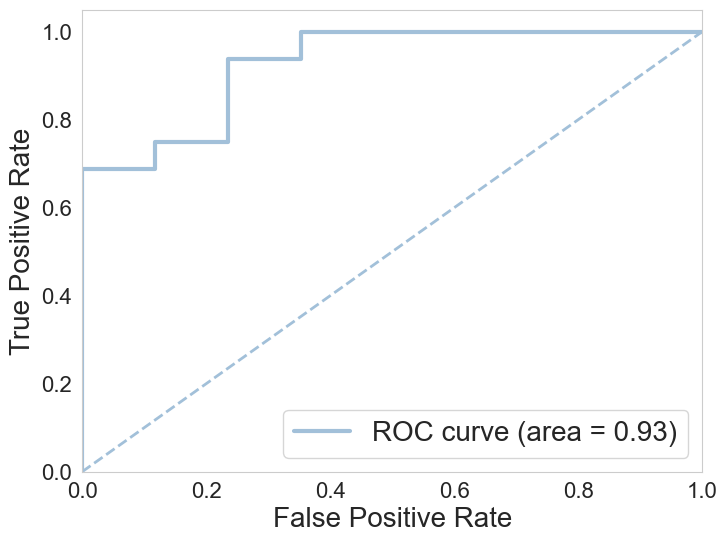

In [24]:
proba_test = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)
print(f"test ROC-AUC = {roc_auc:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#A2C0D9', linewidth=3,
         label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='#A2C0D9', linestyle='--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.legend(loc='lower right', fontsize=20)
plt.tick_params(axis='both', labelsize=16)
plt.grid()
plt.savefig('cor_ML.svg', dpi=700, bbox_inches='tight')
plt.show()


## Feature importance

     Feature  Importance
        tpsa    0.141744
 lipinskiHBD    0.087133
CrippenClogP    0.079605
 lipinskiHBA    0.077551
     exactmw    0.058974


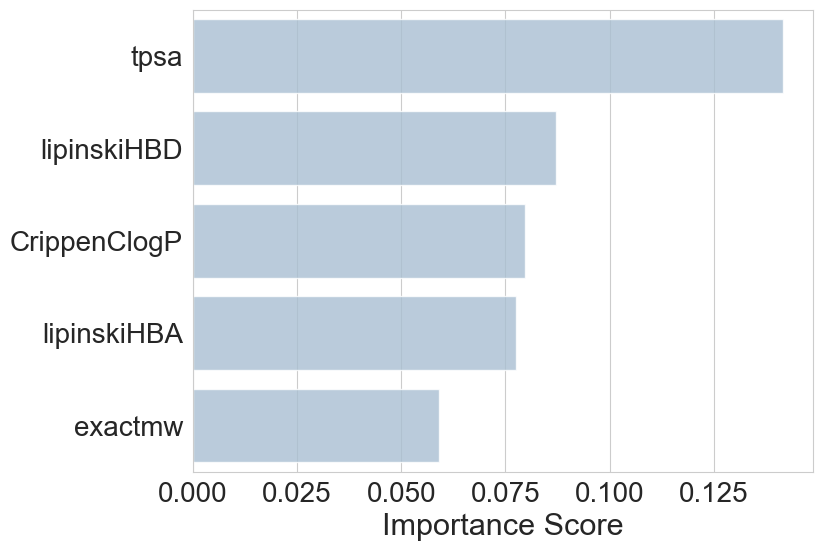

In [25]:
feature_importance_df = pd.DataFrame({
    'Feature': descriptor_names,
    'Importance': final_model.feature_importances_,
}).sort_values(by='Importance', ascending=False)

top5_df = feature_importance_df.head(5)
print(top5_df.to_string(index=False))

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=top5_df,
            color='#A2C0D9', alpha=0.8)
plt.xlabel('Importance Score', fontsize=22)
plt.ylabel('')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.savefig('corr_FI.svg', dpi=700, bbox_inches='tight')
plt.show()


## Save model

In [26]:
joblib.dump(final_model, 'corneal.pkl')
print('saved:', type(final_model).__name__, final_params)


saved: XGBClassifier {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}


## Robustness under scaffold splitting 

In [27]:
def morgan_fp(smi, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)


def scaffold_of(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    except Exception:
        return None


def scaffold_split(smiles_list, test_size=0.2, seed=RANDOM_STATE):
    """Group compounds by Murcko scaffold and assign whole groups to one
    partition. Groups are filled into the test set largest-first, so the test
    set holds the most populated scaffold families and the training set keeps
    the long tail of singletons."""
    scaffolds = {}
    for idx, smi in enumerate(smiles_list):
        scaffolds.setdefault(scaffold_of(smi), []).append(idx)

    groups = list(scaffolds.values())
    rng = np.random.RandomState(seed)
    groups = [groups[i] for i in rng.permutation(len(groups))]
    groups.sort(key=len, reverse=True)

    n_test_target = int(round(len(smiles_list) * test_size))
    test_idx, train_idx = [], []
    for g in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(g)
        else:
            train_idx.extend(g)
    return np.array(train_idx), np.array(test_idx)


def nn_tanimoto_stats(train_smiles, test_smiles):
    train_fps = [f for f in (morgan_fp(s) for s in train_smiles) if f is not None]
    sims = []
    for s in test_smiles:
        fp = morgan_fp(s)
        if fp is None or not train_fps:
            continue
        sims.append(max(DataStructs.BulkTanimotoSimilarity(fp, train_fps)))
    sims = np.array(sims)
    return {
        'mean_NN_Tanimoto': float(np.mean(sims)) if len(sims) else np.nan,
        'median_NN_Tanimoto': float(np.median(sims)) if len(sims) else np.nan,
        'frac_test_with_NN>0.85': float(np.mean(sims > 0.85)) if len(sims) else np.nan,
        'frac_test_with_NN>0.4': float(np.mean(sims > 0.4)) if len(sims) else np.nan,
    }


In [28]:
def eval_split(train_idx, test_idx, label):
    """Evaluate the final model's configuration on a given partition."""
    m = clone(final_model)
    m.fit(X_full[train_idx], y_full[train_idx])
    proba = m.predict_proba(X_full[test_idx])[:, 1]
    pred = m.predict(X_full[test_idx])
    sims = nn_tanimoto_stats(smiles_arr[train_idx], smiles_arr[test_idx])

    row = dict(
        label=label,
        n_train=len(train_idx), n_test=len(test_idx),
        train_pos=float(y_full[train_idx].mean()),
        test_pos=float(y_full[test_idx].mean()),
        auc=roc_auc_score(y_full[test_idx], proba),
        f1=f1_score(y_full[test_idx], pred),
        acc=accuracy_score(y_full[test_idx], pred),
        **sims,
    )
    print(f"--- {label} ---")
    print(f"  n_train={row['n_train']} n_test={row['n_test']}  "
          f"train_pos={row['train_pos']:.2f} test_pos={row['test_pos']:.2f}")
    print(f"  ROC-AUC={row['auc']:.3f}  F1={row['f1']:.3f}  Acc={row['acc']:.3f}")
    print(f"  NN-Tanimoto (test->train): mean={row['mean_NN_Tanimoto']:.3f} "
          f"median={row['median_NN_Tanimoto']:.3f}  "
          f"frac>0.85={row['frac_test_with_NN>0.85']:.2f}  "
          f"frac>0.4={row['frac_test_with_NN>0.4']:.2f}")
    return row


results = [eval_split(tr_idx, te_idx, "Random")]

# The test set holds only ~33 compounds, so a single split is noisy.
seed_aucs = []
for seed in range(N_SEEDS):
    tr_s, te_s = train_test_split(idx_full, test_size=0.2,
                                  random_state=seed, stratify=y_full)
    m = clone(final_model).fit(X_full[tr_s], y_full[tr_s])
    seed_aucs.append(
        roc_auc_score(y_full[te_s], m.predict_proba(X_full[te_s])[:, 1]))

print(f"\nRandom split ROC-AUC over {N_SEEDS} seeds: "
      f"{np.mean(seed_aucs):.3f} +/- {np.std(seed_aucs):.3f}  "
      f"{[round(a, 3) for a in seed_aucs]}\n")

tr_sc, te_sc = scaffold_split(smiles_arr, test_size=0.2, seed=RANDOM_STATE)
results.append(eval_split(tr_sc, te_sc, "Bemis-Murcko scaffold"))

table6 = pd.DataFrame(results)[
    ['label', 'n_train', 'n_test', 'auc',
     'mean_NN_Tanimoto', 'frac_test_with_NN>0.85']
].round(3)

print("\n=== numbers for Table 6 (CP rows) ===")
print(table6.to_string(index=False))
print(f"\n=== hyperparameters for Table 7 ===\n{final_params}")
print(f"\n=== ROC-AUC quoted in the text and in Figure S1 ===\n{roc_auc:.3f}")


--- Random ---
  n_train=129 n_test=33  train_pos=0.50 test_pos=0.48
  ROC-AUC=0.926  F1=0.857  Acc=0.848
  NN-Tanimoto (test->train): mean=0.630 median=0.641  frac>0.85=0.24  frac>0.4=0.73

Random split ROC-AUC over 5 seeds: 0.833 +/- 0.078  [0.688, 0.923, 0.849, 0.857, 0.849]

--- Bemis-Murcko scaffold ---
  n_train=123 n_test=39  train_pos=0.50 test_pos=0.51
  ROC-AUC=0.874  F1=0.810  Acc=0.795
  NN-Tanimoto (test->train): mean=0.323 median=0.309  frac>0.85=0.00  frac>0.4=0.13

=== numbers for Table 6 (CP rows) ===
                label  n_train  n_test   auc  mean_NN_Tanimoto  frac_test_with_NN>0.85
               Random      129      33 0.926             0.630                   0.242
Bemis-Murcko scaffold      123      39 0.874             0.323                   0.000

=== hyperparameters for Table 7 ===
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}

=== ROC-AUC quoted in the text and in Figure S1 ==